### Remap geothermal dataset (Davies, 2013) to tx1_12

In [1]:
%matplotlib inline

In [2]:
import xarray as xr
import xesmf, intake
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

In [3]:
fname = '../mesh/tx1_12_grid_260213.nc'
ds_out = xr.open_dataset(fname).rename({'tlon': 'lon','tlat': 'lat', 'qlon': 'lon_b',
                                        'qlat': 'lat_b', 'nx' : 'xh', 'ny' : 'yh',
                                        'depth' : 'z_l'})
ds_out

<xarray.Dataset> Size: 2GB
Dimensions:  (yh: 3240, xh: 4320, nxp: 4321, nyp: 3241)
Dimensions without coordinates: yh, xh, nxp, nyp
Data variables: (12/20)
    lon      (yh, xh) float64 112MB ...
    lat      (yh, xh) float64 112MB ...
    ulon     (yh, nxp) float64 112MB ...
    ulat     (yh, nxp) float64 112MB ...
    vlon     (nyp, xh) float64 112MB ...
    vlat     (nyp, xh) float64 112MB ...
    ...       ...
    tarea    (yh, xh) float64 112MB ...
    tmask    (yh, xh) float64 112MB ...
    angle    (yh, xh) float64 112MB ...
    z_l      (yh, xh) float64 112MB ...
    ar       (yh, xh) float64 112MB ...
    egs      (yh, xh) float64 112MB ...
Attributes:
    Description:  CESM MOM6 1/12 degree grid
    Author:       Gustavo Marques (gmarques@ucar.edu)
    Created:      2026-02-21T22:23:05.210105
    type:         Glogal 1/12 degree grid file

In [4]:
infile = '/glade/campaign/cgd/oce/datasets/obs/geothermal/geothermal_davies2013_ncar.nc'
ds_in = xr.open_dataset(infile).rename({'tlon': 'lon','tlat': 'lat', 'qlon': 'lon_b',
                                        'qlat': 'lat_b'})
ds_in

<xarray.Dataset> Size: 56MB
Dimensions:        (yh: 1080, xh: 1440, yq: 1081, xq: 1441)
Coordinates:
  * yh             (yh) float32 4kB 0.5 1.5 2.5 ... 1.078e+03 1.078e+03 1.08e+03
  * xh             (xh) float32 6kB 0.5 1.5 2.5 ... 1.438e+03 1.438e+03 1.44e+03
Dimensions without coordinates: yq, xq
Data variables:
    geothermal_hf  (yh, xh) float32 6MB ...
    lat            (yh, xh) float64 12MB ...
    lon            (yh, xh) float64 12MB ...
    lat_b          (yq, xq) float64 12MB ...
    lon_b          (yq, xq) float64 12MB ...
Attributes:
    title:          Geothermal heat flow from Davies, 2013, re-gridded to OM4...
    reference:      Davies, J. Huw, 2013: Global map of solid Earth surface h...
    reference_url:  http://dx.doi.org/10.1002/ggge.20271

In [5]:
def regrid_tracer(fld, ds_in, ds_out, method='conservative'):

    regrid = xesmf.Regridder(
        ds_in,
        ds_out,
        method=method,
        periodic=True,
    )
    fld_out = regrid(ds_in[fld])
    return fld_out

#### Potential temperature

In [6]:
geothermal_hf = regrid_tracer('geothermal_hf', ds_in, ds_out)
geothermal_hf

<xarray.DataArray (yh: 3240, xh: 4320)> Size: 56MB
array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.0530719 , 0.0530719 , 0.0530719 , ..., 0.05337462, 0.05337462,
        0.05337462],
       [0.0530719 , 0.0530719 , 0.0530719 , ..., 0.05337462, 0.05337462,
        0.05337462],
       [0.0530719 , 0.0530719 , 0.0530719 , ..., 0.05337463, 0.05337462,
        0.05337462]], shape=(3240, 4320), dtype=float32)
Dimensions without coordinates: yh, xh
Attributes:
    regrid_method:  conservative

In [7]:
geothermal_hf = geothermal_hf.rename('geothermal_hf')

##### Visual inspection
Make sure original and remapped plots look similar.

Text(0.5, 0.98, 'geothermal_hf')

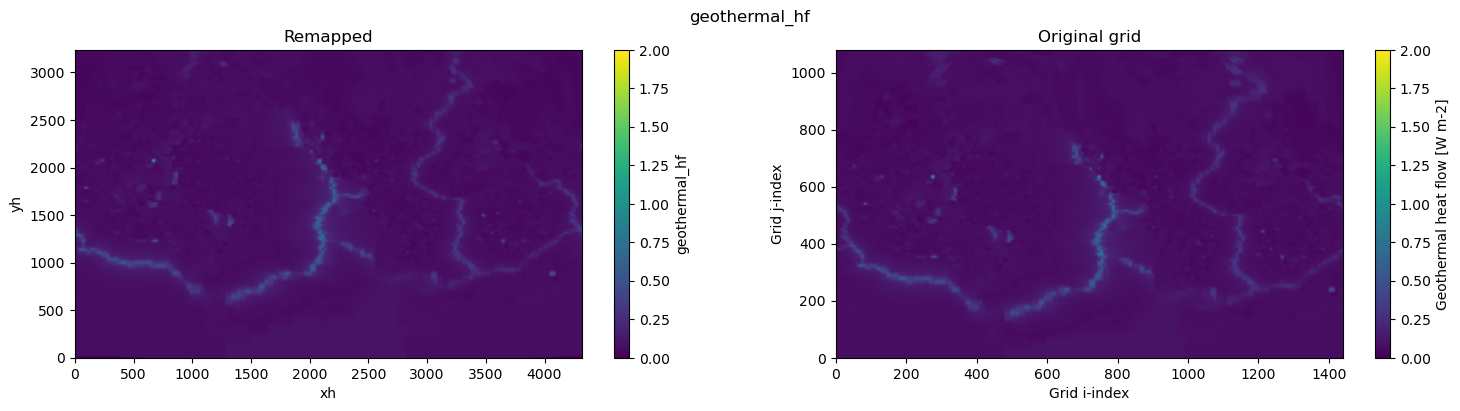

In [8]:
# visual inspection. Make sure original and remapped plots look similar
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18,4))
geothermal_hf.plot.pcolormesh(ax=axes[0], vmin=0,vmax=2)
ds_in['geothermal_hf'].plot.pcolormesh(ax=axes[1], vmin=0,vmax=2)
axes[0].set_title('Remapped')
axes[1].set_title('Original grid')
plt.suptitle('geothermal_hf')

In [9]:
data = xr.DataArray(geothermal_hf.data, dims=('yh', 'xh'), name='geothermal_hf')
data

<xarray.DataArray 'geothermal_hf' (yh: 3240, xh: 4320)> Size: 56MB
array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.0530719 , 0.0530719 , 0.0530719 , ..., 0.05337462, 0.05337462,
        0.05337462],
       [0.0530719 , 0.0530719 , 0.0530719 , ..., 0.05337462, 0.05337462,
        0.05337462],
       [0.0530719 , 0.0530719 , 0.0530719 , ..., 0.05337463, 0.05337462,
        0.05337462]], shape=(3240, 4320), dtype=float32)
Dimensions without coordinates: yh, xh

In [10]:
data

<xarray.DataArray 'geothermal_hf' (yh: 3240, xh: 4320)> Size: 56MB
array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.0530719 , 0.0530719 , 0.0530719 , ..., 0.05337462, 0.05337462,
        0.05337462],
       [0.0530719 , 0.0530719 , 0.0530719 , ..., 0.05337462, 0.05337462,
        0.05337462],
       [0.0530719 , 0.0530719 , 0.0530719 , ..., 0.05337463, 0.05337462,
        0.05337462]], shape=(3240, 4320), dtype=float32)
Dimensions without coordinates: yh, xh

In [11]:
data = xr.DataArray(geothermal_hf.data, dims=('yh', 'xh'), name='geothermal_hf')

# Global attrs
data.attrs['long_name'] = 'Geothermal heat flow'
data.attrs['standard_name'] = 'upward_geothermal_heat_flux_at_sea_floor'
data.attrs['units'] = 'W m-2'
data.attrs['cell_methods'] = 'area: mean'

# Create a dataset and add the DataArray to it
dataset = xr.Dataset({'geothermal_hf': data})

dataset.attrs['description'] = 'Geothermal heat flow from Davies, 2013, re-gridded to tx1_12'
dataset.attrs['author'] = 'Gustavo Marques (gmarques@ucar.edu)'
dataset.attrs['date'] = datetime.now().isoformat()
dataset.attrs['infile'] = infile
dataset.attrs['url'] = 'https://github.com/NCAR/tx1_12/geothermal'
# save
fname = 'geothermal_davies2013_tx1_12_260213.nc'

dataset.to_netcdf(fname, encoding={'geothermal_hf': {'_FillValue': None}})

In [12]:
!nccopy -k cdf5 geothermal_davies2013_tx1_12_260213.nc geothermal_davies2013_tx1_12_260213_cdf5.nc